# rocky, temperate candidate counts by spectral category
- top: crossmatched sample, bottom: entire Exo-MerCat; dark = confirmed, light = uncertain
- exports to `report/figures/rocky_temperate_yield.pdf`

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, pathlib

ROOT = pathlib.Path.cwd()
while not (ROOT / 'crossmatching').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt

from report_plots import common, data, plots


In [2]:
cme, input_table, matched = data.emc_crossmatch()
merger = data.build_param_filler()

e_cm_emc = data.enrich(matched, cme, merger)
e_emc = data.enrich(cme.catalog_table, cme, merger)
data.compute_is_rocky_temperate(e_cm_emc)
data.compute_is_rocky_temperate(e_emc)
data.rocky_temperate_summary(e_cm_emc=e_cm_emc, e_emc=e_emc)


e_cm_emc: 7 Confirmed + 13 Uncertain rocky, temperate planets
e_emc: 17 Confirmed + 66 Uncertain rocky, temperate planets


saved /home/joshuadreier/Documents/CodingProjects/SemesterProjectEHG/paper/figures/rocky_temp_yield.pdf


PosixPath('/home/joshuadreier/Documents/CodingProjects/SemesterProjectEHG/paper/figures/rocky_temp_yield.pdf')

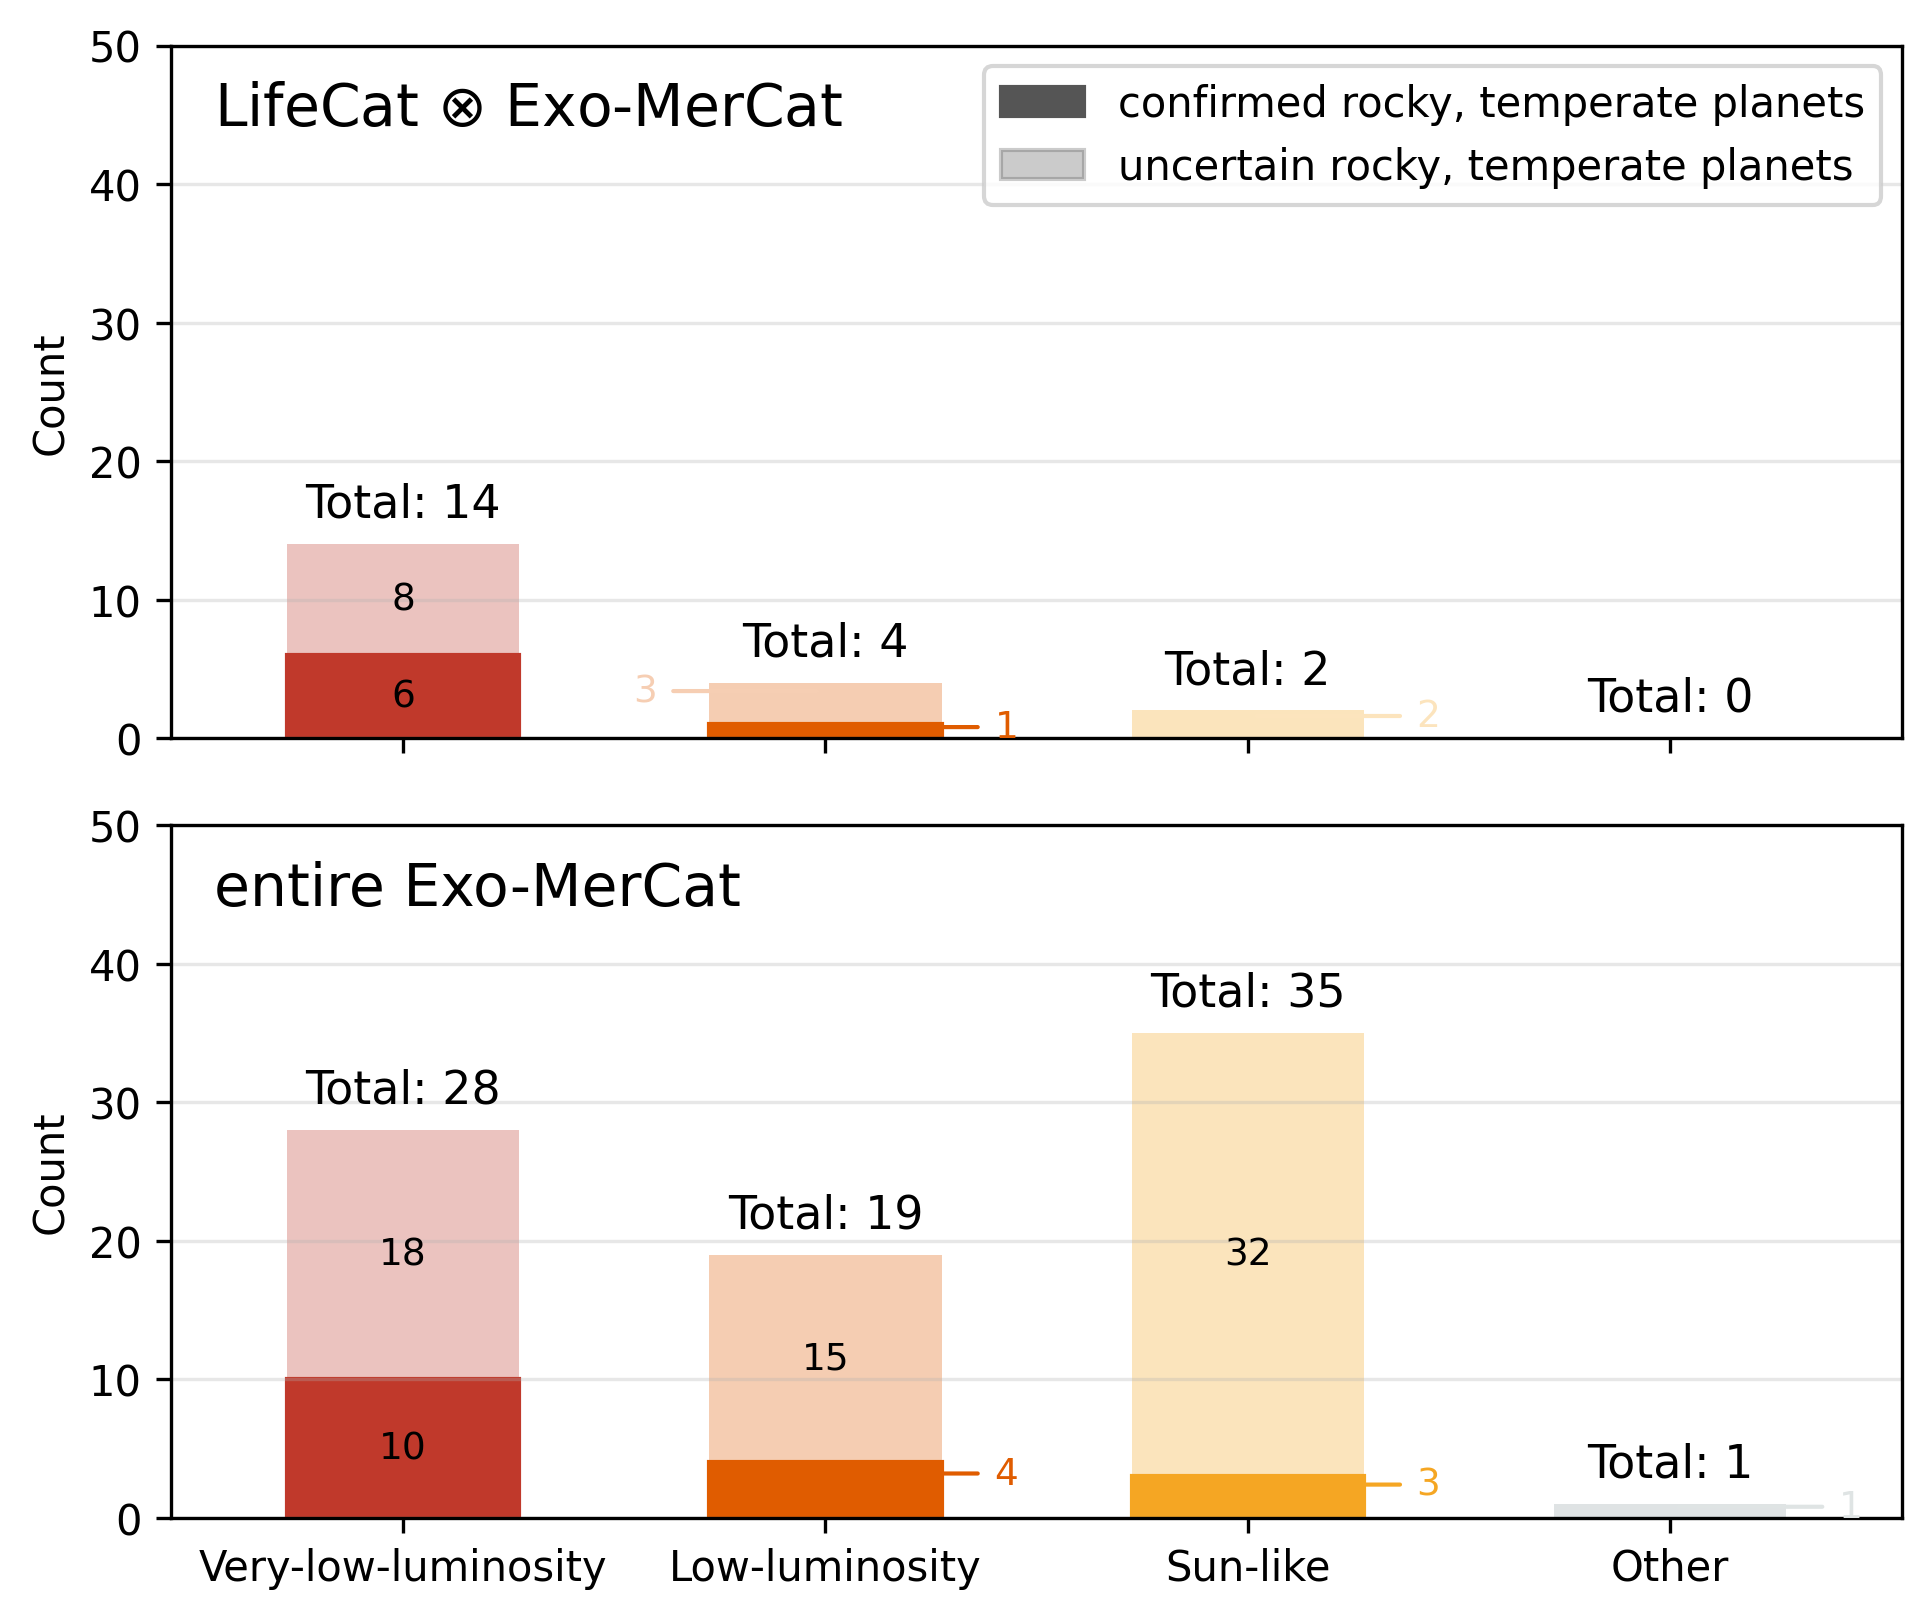

In [3]:
fig, ax = plt.subplots(2, figsize=(6.5, 5.5), sharex=True)
plt.tight_layout()
ax[0].grid(axis='y', alpha=0.3)
ax[1].grid(axis='y', alpha=0.3)
plots.plot_rocky_temp_bars(ax[0], e_cm_emc, "", 50)
plots.plot_rocky_temp_bars(ax[1], e_emc, "", 50)
ax[0].text(0.025, 0.95, r'LifeCat $\otimes$ Exo-MerCat',
    horizontalalignment='left',
    verticalalignment='top',
    transform=ax[0].transAxes,
    fontsize=14,
)
ax[1].text(0.025, 0.95, 'entire Exo-MerCat',
    horizontalalignment='left',
    verticalalignment='top',
    transform=ax[1].transAxes,
    fontsize=14,
)

ax[1].get_legend().remove()
common.save_figure("rocky_temperate_yield")
